# BackTesting 

## Import libraries

In [58]:
import os, sys
processing_source_path = os.path.abspath('Processing/')
if(processing_source_path not in sys.path):
    sys.path.append(processing_source_path)
from ProcessingPipeline import FeaturesDataGenerator, scrapingHistoricalData

In [59]:
import tensorflow as tf
import requests
import pandas as pd
import numpy as np

### Get the crypto data

In [60]:

SHD=scrapingHistoricalData()

# Lista de criptomoedas
cryptos = ['BTC']

# Escolha o intervalo
interval = '4h'

# Obtenha os dados históricos
cryptos_df = SHD.get_crypto_historical_data(cryptos, interval, '2019-01-01')

In [61]:
features_indicators=['Data_lookback', 'Open', 'High', 'Low', 'Volume', 
                    'EMA9', 'EMA20', 'EMA50', 'EMA100', 'EMA200', 'MA111', 'MA350', 
                    'MACD', 'MACD_Signal', 'MACD_Histogram', 'RSI_14', 'CCI',  
                    'Stochastic_K', 'Stochastic_D', 
                    'Bollinger_Bands_Upper', 'Bollinger_Bands_Middle', 'Bollinger_Bands_Lower']

features_indicators=['Data_lookback','Chaikin_Money_Flow',
                    'EMA9', 'EMA20', 'EMA50', 'EMA100', 'EMA200',
                    'MACD', 'MACD_Signal', 'MACD_Histogram', 'RSI_14', 'CCI',  
                    'Stochastic_K', 'Stochastic_D', 
                    'Bollinger_Bands_Upper', 'Bollinger_Bands_Middle', 'Bollinger_Bands_Lower']

features_indicators=[
                    'EMA9', 'EMA20', 'EMA50', 'EMA100', 'EMA200',
                    'MA111', 'MA350', 
                    #'RSI_14',  
                    #'MACD', 'MACD_Signal', 'MACD_Histogram',
                    'Bollinger_Bands_Upper', 'Bollinger_Bands_Middle', 'Bollinger_Bands_Lower']
                    #''CCI','Williams_R',  'ROC',  'PPO', 'Chaikin_Money_Flow']
features_indicators=['Data_lookback', 'Open', 'High', 'Low', 
                    'EMA9', 'EMA20', 'EMA50', 'EMA100', 'EMA200', 'MA111', 'MA350', 
                    'RSI_14',  'Chaikin_Money_Flow',
                    'MACD', 'MACD_Signal', 'MACD_Histogram', 
                    'Stochastic_K', 'Stochastic_D', 
                    'Bollinger_Bands_Upper', 'Bollinger_Bands_Middle', 'Bollinger_Bands_Lower',
                    'CCI',  'ROC',  'PPO', 'Chaikin_Money_Flow']

In [62]:
#pred_days = int(24/4 * 12) 
pred_days = int(24/4 * 2) 
buy_sell_threshold=[0.05,-0.05]
lookback = int(4 * 6) 
batch_size = 16
shuffle = True

min_norm=-1
max_norm=1
ticker = 'BTC-USDT'
#list_of_models =['MLP', 'GRU', 'CNN_LSTM_MultiHead', 'CNN_MultiHead', 'LSTM', 'LSTM_AT']
list_of_models =['CNN_MultiHead']


In [63]:
# features and dataloader parameters
features_indicators=['Close', 'Open', 'High', 'Low',  
                    'EMA9', 'EMA20', 'EMA50', 'EMA100', 'EMA200', 'MA111', 'MA350', 
                    'RSI_14', 
                    'MACD', 'MACD_Signal', 'MACD_Histogram', 
                    'Stochastic_K', 'Stochastic_D', 
                    'Bollinger_Bands_Upper', 'Bollinger_Bands_Middle', 'Bollinger_Bands_Lower',
                    'CCI',  'ROC', 'Chaikin_Money_Flow']

pred_days = int(24/4 * 2.5) 
buy_sell_threshold=[0.05,-0.05]
lookback = int(4 * 8) 
batch_size = 16
shuffle = True

min_norm=-1
max_norm=1

trade=['Hold','Buy','Sell']

# model parameters
input_shape = (lookback, len(features_indicators))
n_classes = len(trade)



In [64]:
dataGen_inference = FeaturesDataGenerator(cryptos_df, lookback = lookback, pred_days = pred_days, shuffle= False, batch_size=1, selected_features = features_indicators, data_augmentation=False, min_max_norm=[min_norm, max_norm])

self.pred_days 15


d:\Projetos_python\Time_Series_Forecast\acoes\Processing\ProcessingPipeline.py:331: RuntimeWarning:

divide by zero encountered in divide



input data shape (11968, 32, 23)
output data shape (11968, 3)


### Load the model

In [65]:
from keras import backend as K
weighted_categorical_crossentropy_loss= dataGen_inference.weighted_categorical_crossentropy(np.ones(3))

def matthews_correlation_coefficient(y_true, y_pred):
    tp = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    tn = K.sum(K.round(K.clip((1 - y_true) * (1 - y_pred), 0, 1)))
    fp = K.sum(K.round(K.clip((1 - y_true) * y_pred, 0, 1)))
    fn = K.sum(K.round(K.clip(y_true * (1 - y_pred), 0, 1)))

    num = tp * tn - fp * fn
    den = (tp + fp) * (tp + fn) * (tn + fp) * (tn + fn)
    return num / K.sqrt(den + K.epsilon())

In [66]:

trained_best_models={}
for model_name in list_of_models:
    print(model_name)
    #checkpoint_filepath =f'models/model_{model_name}_stock_{ticker}_lookback_{lookback}'
    checkpoint_filepath =f'models/model_{model_name}_crypto_lookback_{lookback}'
    trained_best_models[f'{model_name}']=tf.keras.models.load_model(
        checkpoint_filepath,
        custom_objects={'loss': weighted_categorical_crossentropy_loss, 'matthews_correlation_coefficient': matthews_correlation_coefficient})

CNN_MultiHead


In [67]:
x_data_inference=dataGen_inference.comput_features(cryptos_df, pred_days=0)
x_data=dataGen_inference.apply_NomrMinmax(x_data_inference, min_norm, max_norm, axis=0)
model_name='CNN_MultiHead'
label_pred = trained_best_models[model_name].predict(x_data)

d:\Projetos_python\Time_Series_Forecast\acoes\Processing\ProcessingPipeline.py:331: RuntimeWarning:

divide by zero encountered in divide



374/374 [==============================] - 5s 10ms/step


In [68]:
label_pred

array([[8.5931003e-01, 2.3235613e-02, 1.1745424e-01],
       [7.7072239e-01, 1.6853765e-02, 2.1242383e-01],
       [1.7749898e-01, 5.8930350e-04, 8.2191169e-01],
       ...,
       [5.4029459e-01, 2.0338330e-01, 2.5632215e-01],
       [4.8966330e-01, 1.1666029e-01, 3.9367646e-01],
       [3.9763173e-01, 5.1354885e-01, 8.8819459e-02]], dtype=float32)

### Show inference

In [69]:
trade=['Hold','Buy','Sell']

In [70]:
label_data = dataGen_inference.label_data(close_prices=cryptos_df['Close'].values, window=16)


In [71]:
data_idx= -x_data_inference.shape[0]
input_data = cryptos_df['Close'].iloc[data_idx:].values
inference_date = cryptos_df['Date'].iloc[data_idx:]

pred_signals=[trade[label] for label in np.argmax(label_pred[:],axis=1)]
pred_signals=pred_signals[data_idx:]

cryptos_df['pred_signals']=['Hold']*len(cryptos_df)
cryptos_df['pred_signals'].iloc[data_idx:]= pred_signals

C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_21684\1240729710.py:9: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [72]:
#cryptos_df['label_data'] = ['Hold']*len(cryptos_df)


In [73]:
# Dados de exemplo
close_price_list = cryptos_df['Close'].values

#labels = labelling_method(close_price_list, 60)
label_data = dataGen_inference.label_data(close_prices=cryptos_df['Close'], window= 6)

labels=[("BUY" if np.allclose(label, [0, 1, 0]) else "SELL" if np.allclose(label, [0, 0, 1]) else "HOLD") 
        for label in label_data]# Realizar o backtest

cryptos_df['label_data'] = labels

print('labeling method ',np.unique(labels, return_counts=True))
print('Predicted ',np.unique(cryptos_df['pred_signals'], return_counts=True))

# Realizar o backtest

signals=[trade[label] for label in np.argmax(label_pred[:],axis=1)]
signals=signals[data_idx:]

# Gráfico do desempenho
import plotly.graph_objects as go

#fig = go.Figure()

fig = go.Figure(data=[go.Candlestick(x=cryptos_df['Date'],
                open=cryptos_df['Open'],
                high=cryptos_df['High'],
                low=cryptos_df['Low'],
                close=cryptos_df['Close'],
                name='Candlestick')])


# Configuração do layout
fig.update_layout(
    title="Backtest de Estratégia de BUY, SELL, HOLD",
    xaxis_title="Data",
    yaxis_title="Valor",
    showlegend=False,
    width=1700,
    height=600,
    margin=dict(l=50, r=50, t=50, b=50)  # Margem esquerda, direita, superior e inferior
)


# Adiciona os marcadores BUY, SELL e HOLD
for i, label in enumerate(labels):

    if label == "BUY":
        fig.add_trace(go.Scatter(
            x=[cryptos_df['Date'].iloc[i]],
            y=[cryptos_df['Close'].iloc[i]- 0.03*cryptos_df['Close'].iloc[i]] ,
            mode='markers',
            marker=dict(color='green', size=10, symbol='triangle-up'),
            name='BUY'
        ))
    elif label == "SELL":
        fig.add_trace(go.Scatter(
            x=[cryptos_df['Date'].iloc[i]],
            y=[cryptos_df['Close'].iloc[i]+ 0.03*cryptos_df['Close'].iloc[i]],
            mode='markers',
            marker=dict(color='red', size=10, symbol='triangle-down'),
            name='SELL'
        ))
    
    if cryptos_df['pred_signals'].iloc[i] == "Buy":
        fig.add_trace(go.Scatter(
            x=[cryptos_df['Date'].iloc[i]],
            y=[cryptos_df['Close'].iloc[i]- 0.06*cryptos_df['Close'].iloc[i]] ,
            mode='markers',
            marker=dict(color='white', size=10, symbol='diamond'),
            name='pred BUY'
        ))
    elif cryptos_df['pred_signals'].iloc[i] == "Sell":
        fig.add_trace(go.Scatter(
            x=[cryptos_df['Date'].iloc[i]],
            y=[cryptos_df['Close'].iloc[i]+ 0.06*cryptos_df['Close'].iloc[i]],
            mode='markers',
            marker=dict(color='black', size=10, symbol='diamond'),
            name='pred SELL'
        ))
        
fig.update_layout(xaxis_rangeslider_visible=False)
fig.show()


labeling method  (array(['BUY', 'HOLD', 'SELL'], dtype='<U4'), array([1247, 9509, 1244], dtype=int64))
Predicted  (array(['Buy', 'Hold', 'Sell'], dtype=object), array([3264, 6046, 2690], dtype=int64))


In [74]:
# Classe para gerenciar o backtesting
import matplotlib.pyplot as plt

class Backtester:
    def __init__(self, initial_balance, data):
        self.initial_balance = initial_balance
        self.data = data
        self.balance = initial_balance
        self.position = 0
        self.portfolio_value = []

    def execute_trade(self, signal, price):
        if signal == 'Buy' and self.balance > 0:
            self.position = self.balance / price
            self.balance = 0
        elif signal == 'Sell' and self.position > 0:
            self.balance = self.position * price
            self.position = 0

    def run(self, signals):
        for i in range(len(self.data)):
            price = self.data['Close'].iloc[i]
            signal = signals[i]

            self.execute_trade(signal, price)
            portfolio_value = self.balance + (self.position * price)
            self.portfolio_value.append(portfolio_value)

    def plot_results(self):
        plt.figure(figsize=(12, 6))
        plt.plot(self.data.index, self.portfolio_value, label='Portfolio Value')
        plt.xlabel('Date')
        plt.ylabel('Value')
        plt.title('Portfolio Performance')
        plt.legend()
        plt.show()

# Função para gerar sinais fictícios
def generate_signals(signals):
    trade_signals = ['Hold']
    for i in range(1,len(signals)):
        if signals[i] == 'Buy' and signals[i-1] == 'Buy':
            trade_signals.append('Hold')
        elif signals[i] == 'Buy' and signals[i-1] == 'Hold':
            trade_signals.append('Buy')
        elif signals[i] == 'Sell' and signals[i-1] == 'Sell':
            trade_signals.append('Hold')

        elif signals[i] == 'Sell' and signals[i-1] == 'Hold':
            trade_signals.append('Sell')
        else:
            trade_signals.append('Hold')


    return trade_signals

d:\Projetos_python\Time_Series_Forecast\acoes\Processing\ProcessingPipeline.py:790: RuntimeWarning:

divide by zero encountered in log

d:\Projetos_python\Time_Series_Forecast\acoes\Processing\ProcessingPipeline.py:331: RuntimeWarning:

divide by zero encountered in divide



463/463 [==============================] - 3s 7ms/step
(array(['Buy', 'Hold', 'Sell'], dtype='<U4'), array([4093, 7410, 3287], dtype=int64))


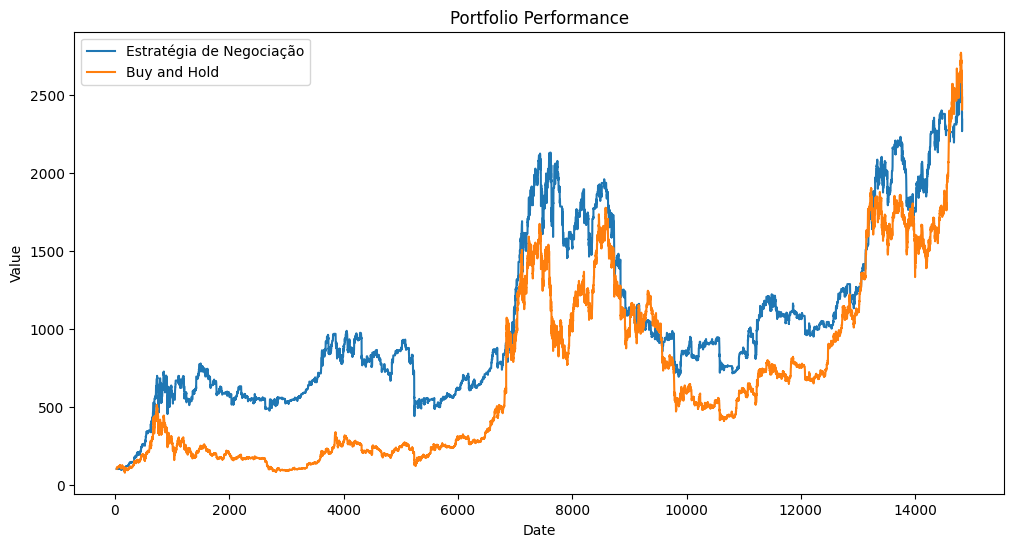

Retorno da Estratégia de Negociação: 2240.81%
Retorno da Estratégia de Buy and Hold: 2381.86%


In [81]:


# Parâmetros iniciais
interval = '4h'
start_time = '2013-01-01'
initial_balance = 100

# Coleta de dados
data = SHD.get_crypto_historical_data(symbol, interval, start_time)

if data.empty:
    print("Nenhum dado encontrado.")
else:
    # Geração de sinais e backtesting

    x_data_inference=dataGen_inference.comput_features(data, pred_days=0)
    x_data=dataGen_inference.apply_NomrMinmax(x_data_inference, min_norm, max_norm, axis=0)
    
    #list_of_models =['MLP', 'GRU', 'CNN_LSTM_MultiHead', 'CNN_MultiHead', 'LSTM', 'LSTM_AT']
    model_name='CNN_MultiHead'
    label_pred = trained_best_models[model_name].predict(x_data)

    signals = [trade[label] for label in np.argmax(label_pred[:], axis=1)]
    print(np.unique(signals, return_counts=True))
    #trade_signals=generate_signals(signals)
    
    trade_signals=signals
    data=data.iloc[-len(signals):,:]


    backtester = Backtester(initial_balance, data)
    backtester.run(trade_signals)
    #backtester.plot_results()

    # Estratégia de buy and hold
    buy_and_hold = Backtester(initial_balance, data)
    signals = ['Buy'] + ['Hold'] * (len(data) - 1)
    buy_and_hold.run(signals)
    buy_and_hold_value = buy_and_hold.portfolio_value

    # Plotar resultados
    plt.figure(figsize=(12, 6))
    plt.plot(backtester.data.index, backtester.portfolio_value, label='Estratégia de Negociação')
    plt.plot(buy_and_hold.data.index, buy_and_hold_value, label='Buy and Hold')
    plt.xlabel('Date')
    plt.ylabel('Value')
    plt.title('Portfolio Performance')
    plt.legend()
    plt.show()

    # Calcular retorno
    backtester_return = (backtester.portfolio_value[-1] - initial_balance) / initial_balance
    buy_and_hold_return = (buy_and_hold_value[-1] - initial_balance) / initial_balance

    print(f"Retorno da Estratégia de Negociação: {backtester_return * 100:.2f}%")
    print(f"Retorno da Estratégia de Buy and Hold: {buy_and_hold_return * 100:.2f}%")

In [76]:
data['Close'].values.shape

(9968,)

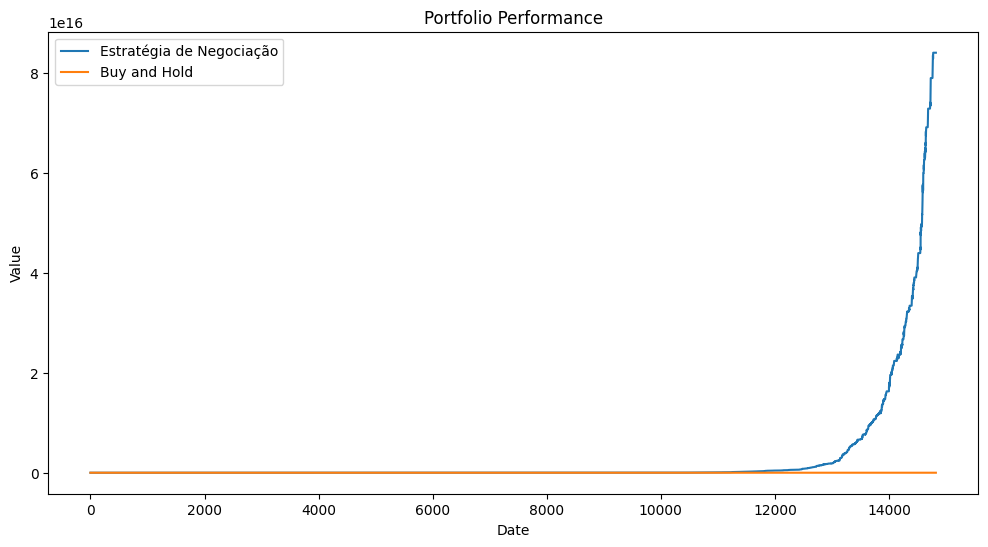

Retorno da Estratégia de Negociação: 84005884195230400.00%
Retorno da Estratégia de Buy and Hold: 2095.96%


In [79]:
data = SHD.get_crypto_historical_data(symbol, interval, start_time)

label_data = dataGen_inference.label_data(close_prices=data['Close'].values, window=16)

trade_signals=[("Buy" if np.allclose(label, [0, 1, 0]) else "Sell" if np.allclose(label, [0, 0, 1]) else "Hold") 
        for label in label_data]# Realizar o backtest

data=data.iloc[:len(trade_signals),:]

backtester = Backtester(initial_balance, data)
backtester.run(trade_signals)

# Estratégia de buy and hold
buy_and_hold = Backtester(initial_balance, data)
signals = ['Buy'] + ['Hold'] * (len(data) - 1)
buy_and_hold.run(signals)
buy_and_hold_value = buy_and_hold.portfolio_value

# Plotar resultados
plt.figure(figsize=(12, 6))
plt.plot(backtester.data.index, backtester.portfolio_value, label='Estratégia de Negociação')
plt.plot(buy_and_hold.data.index, buy_and_hold_value, label='Buy and Hold')
plt.xlabel('Date')
plt.ylabel('Value')
plt.title('Portfolio Performance')
plt.legend()
plt.show()

# Calcular retorno
backtester_return = (backtester.portfolio_value[-1] - initial_balance) / initial_balance
buy_and_hold_return = (buy_and_hold_value[-1] - initial_balance) / initial_balance

print(f"Retorno da Estratégia de Negociação: {backtester_return * 100:.2f}%")
print(f"Retorno da Estratégia de Buy and Hold: {buy_and_hold_return * 100:.2f}%")